In [1]:
from datascience import *
%matplotlib inline
path_data = '../../../assets/data/'
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
import numpy as np
import warnings
warnings.simplefilter(action='ignore', category=DeprecationWarning)


## Lecture 12 ##

## A Join Example ##

In [2]:
full = Table.read_table('nc-est2019-agesex-res.csv')
census = full.select('SEX', 'AGE', 'POPESTIMATE2019')
census.show(3)

SEX,AGE,POPESTIMATE2019
0,0,3783052
0,1,3829599
0,2,3922044


In [3]:
sex_codes = Table().with_columns(
    'SEX CODE', make_array(0, 1, 2),
    'CODE DEFINITION', make_array('All', 'Selected Male', 'Selected Female')
)
sex_codes

SEX CODE,CODE DEFINITION
0,All
1,Selected Male
2,Selected Female


In [4]:
sex_codes.join('SEX CODE', census, 'SEX').sort('AGE').show(3)

SEX CODE,CODE DEFINITION,AGE,POPESTIMATE2019
0,All,0,3783052
1,Selected Male,0,1935117
2,Selected Female,0,1847935


## Bike Sharing ##
Describe the incoming data set

Note: Duration is in seconds. 

In [5]:
trip = Table.read_table('trip.csv')
trip.show(15)

Trip ID,Duration,Start Date,Start Station,Start Terminal,End Date,End Station,End Terminal,Bike #,Subscriber Type,Zip Code
913460,765,8/31/2015 23:26,Harry Bridges Plaza (Ferry Building),50,8/31/2015 23:39,San Francisco Caltrain (Townsend at 4th),70,288,Subscriber,2139
913459,1036,8/31/2015 23:11,San Antonio Shopping Center,31,8/31/2015 23:28,Mountain View City Hall,27,35,Subscriber,95032
913455,307,8/31/2015 23:13,Post at Kearny,47,8/31/2015 23:18,2nd at South Park,64,468,Subscriber,94107
913454,409,8/31/2015 23:10,San Jose City Hall,10,8/31/2015 23:17,San Salvador at 1st,8,68,Subscriber,95113
913453,789,8/31/2015 23:09,Embarcadero at Folsom,51,8/31/2015 23:22,Embarcadero at Sansome,60,487,Customer,9069
913452,293,8/31/2015 23:07,Yerba Buena Center of the Arts (3rd @ Howard),68,8/31/2015 23:12,San Francisco Caltrain (Townsend at 4th),70,538,Subscriber,94118
913451,896,8/31/2015 23:07,Embarcadero at Folsom,51,8/31/2015 23:22,Embarcadero at Sansome,60,363,Customer,92562
913450,255,8/31/2015 22:16,Embarcadero at Sansome,60,8/31/2015 22:20,Steuart at Market,74,470,Subscriber,94111
913449,126,8/31/2015 22:12,Beale at Market,56,8/31/2015 22:15,Temporary Transbay Terminal (Howard at Beale),55,439,Subscriber,94130
913448,932,8/31/2015 21:57,Post at Kearny,47,8/31/2015 22:12,South Van Ness at Market,66,472,Subscriber,94702


## Distribution of Durations ##

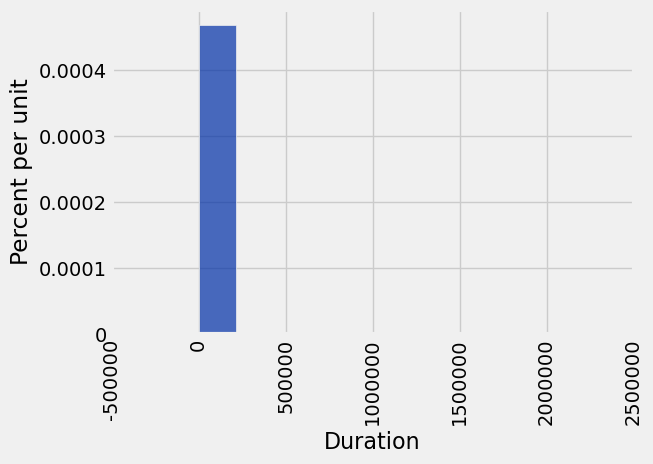

In [6]:
trip.hist('Duration')

Review the horizontal axis. Any guesses as to why the values are so high?

Let's check the data...

In [7]:
trip.sort('Duration', descending=True)

Trip ID,Duration,Start Date,Start Station,Start Terminal,End Date,End Station,End Terminal,Bike #,Subscriber Type,Zip Code
825850,2137000,6/28/2015 21:50,Market at Sansome,77,7/23/2015 15:27,Yerba Buena Center of the Arts (3rd @ Howard),68,466,Customer,97213
750192,1852590,5/2/2015 6:17,San Antonio Shopping Center,31,5/23/2015 16:53,Castro Street and El Camino Real,32,680,Subscriber,94024
841176,1133540,7/10/2015 10:35,University and Emerson,35,7/23/2015 13:27,University and Emerson,35,262,Customer,94306
774999,688899,5/20/2015 15:27,Palo Alto Caltrain Station,34,5/28/2015 14:49,California Ave Caltrain Station,36,230,Customer,nil
635260,655939,2/8/2015 3:05,San Jose Civic Center,3,2/15/2015 17:17,SJSU 4th at San Carlos,12,132,Customer,89451
745640,611240,4/29/2015 9:41,University and Emerson,35,5/6/2015 11:28,San Antonio Shopping Center,31,196,Customer,81
635263,602338,2/8/2015 3:09,San Jose Civic Center,3,2/15/2015 2:28,San Jose Civic Center,3,9,Customer,89451
779645,594550,5/24/2015 13:33,San Pedro Square,6,5/31/2015 10:42,San Pedro Square,6,39,Customer,95118
812544,552697,6/18/2015 10:45,Mountain View Caltrain Station,28,6/24/2015 20:17,Palo Alto Caltrain Station,34,70,Customer,90024
661326,531240,2/27/2015 15:45,San Jose Diridon Caltrain Station,2,3/5/2015 19:19,SJSU 4th at San Carlos,12,662,Customer,95112


What could have caused those high duration values? (Remember, duration is in seconds.)


Let's limit the duration to a realistic value. 
Check the limit below, what is that in minutes?

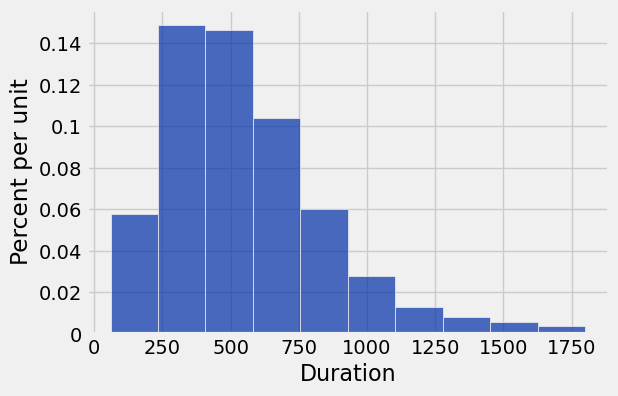

In [8]:
commute = trip.where('Duration', are.below(1800))
commute.hist('Duration')

Describe the shape of the histogram.

What does that tell us about the data?

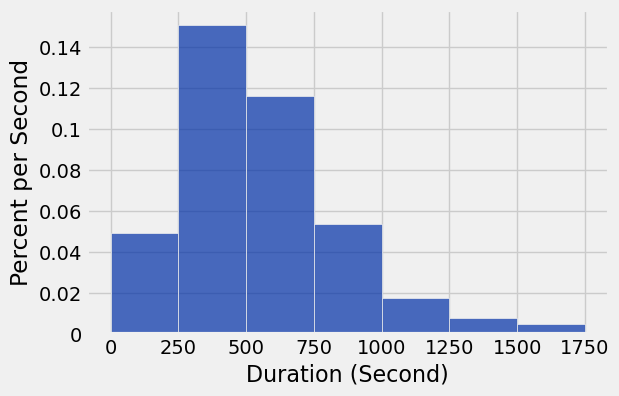

In [9]:
commute.hist('Duration', bins=np.arange(0, 1800, 250), unit='Second')

The histogram above is the same data as the previous histogram but displayed differently.
What was changed and how was it changed?

Which view do you prefer and why?

In [10]:
# Approx percent of people who have # a ride duration between 250 and 500 seconds
# "between" = [250, 500) 
# Recall: The area of the histogram bar gives on the percent of people. 
# (since the vertical axis is the percent per second)

(500-250) * 0.15 

37.5

In [11]:
# Determine how many commutes were in the 250 to 500 category.

count_250 = commute.where('Duration', are.between(250, 500)).num_rows
count_250

75354

In [12]:
# Determine the total number of commutes recorded in this sample.

total_commutes = commute.num_rows
total_commutes

200033

In [13]:
# Determine the decimal value of that ratio. 
# How close is it to the histograms display?
count_250 / total_commutes

0.37670784320587103

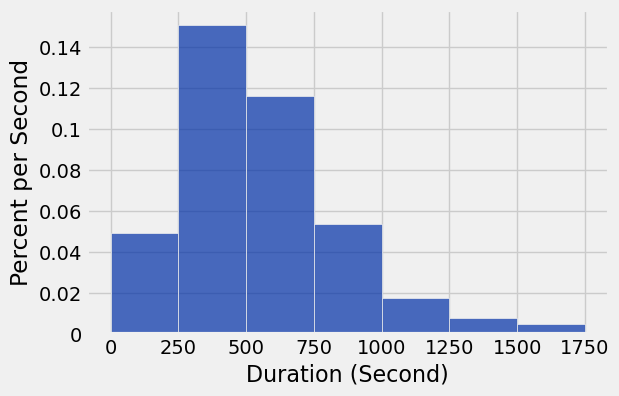

In [14]:
commute.hist('Duration', bins=np.arange(0, 1800, 250), unit='Second')

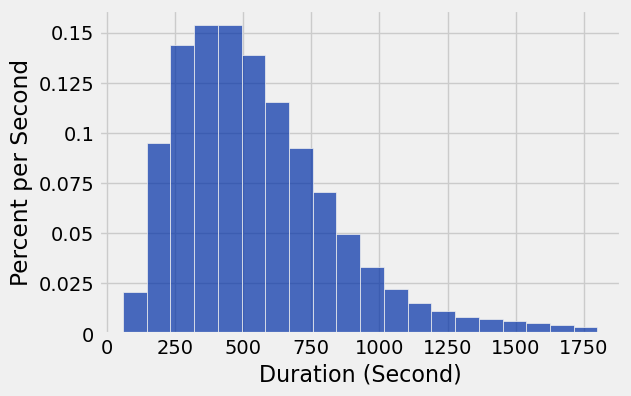

In [16]:
commute.hist('Duration', bins=20, unit='Second')

Describe the new histogram.

What changed?

Which display of the three would you prefer to view to interpret this data set? Why?

## Start and End Stations ##

In [17]:
# Most common start station

starts = commute.group('Start Station').sort('count', descending=True)
starts

Start Station,count
San Francisco Caltrain (Townsend at 4th),14352
San Francisco Caltrain 2 (330 Townsend),13307
Harry Bridges Plaza (Ferry Building),9619
Temporary Transbay Terminal (Howard at Beale),8489
Townsend at 7th,8167
Steuart at Market,8109
2nd at Townsend,8013
Embarcadero at Sansome,7968
Market at 10th,6577
Market at Sansome,6265


In [20]:
# Numbers of trips between stations

commute.pivot('Start Station', 'End Station')

End Station,2nd at Folsom,2nd at South Park,2nd at Townsend,5th at Howard,Adobe on Almaden,Arena Green / SAP Center,Beale at Market,Broadway St at Battery St,California Ave Caltrain Station,Castro Street and El Camino Real,Civic Center BART (7th at Market),Clay at Battery,Commercial at Montgomery,Cowper at University,Davis at Jackson,Embarcadero at Bryant,Embarcadero at Folsom,Embarcadero at Sansome,Embarcadero at Vallejo,Evelyn Park and Ride,Franklin at Maple,Golden Gate at Polk,Grant Avenue at Columbus Avenue,Harry Bridges Plaza (Ferry Building),Howard at 2nd,Japantown,MLK Library,Market at 10th,Market at 4th,Market at Sansome,Mechanics Plaza (Market at Battery),Mezes Park,Mountain View Caltrain Station,Mountain View City Hall,Palo Alto Caltrain Station,Park at Olive,Paseo de San Antonio,Post at Kearny,Powell Street BART,Powell at Post (Union Square),Redwood City Caltrain Station,Redwood City Medical Center,Redwood City Public Library,Rengstorff Avenue / California Street,Ryland Park,SJSU - San Salvador at 9th,SJSU 4th at San Carlos,San Antonio Caltrain Station,San Antonio Shopping Center,San Francisco Caltrain (Townsend at 4th),San Francisco Caltrain 2 (330 Townsend),San Francisco City Hall,San Jose City Hall,San Jose Civic Center,San Jose Diridon Caltrain Station,San Mateo County Center,San Pedro Square,San Salvador at 1st,Santa Clara County Civic Center,Santa Clara at Almaden,South Van Ness at Market,Spear at Folsom,St James Park,Stanford in Redwood City,Steuart at Market,Temporary Transbay Terminal (Howard at Beale),Townsend at 7th,University and Emerson,Washington at Kearny,Yerba Buena Center of the Arts (3rd @ Howard)
2nd at Folsom,31,105,336,73,0,0,24,5,0,0,27,34,35,0,8,23,23,29,10,0,0,4,11,323,37,0,0,111,73,138,24,0,0,0,0,0,0,34,39,30,0,0,0,0,0,0,0,0,0,390,267,15,0,0,0,0,0,0,0,0,30,33,0,0,28,190,251,0,5,18
2nd at South Park,96,77,31,124,0,0,117,52,0,0,25,45,94,0,18,27,125,58,62,0,0,34,35,383,264,0,0,34,83,813,61,0,0,0,0,0,0,165,38,64,0,0,0,0,0,0,0,0,0,308,172,28,0,0,0,0,0,0,0,0,41,69,0,0,219,171,86,0,44,86
2nd at Townsend,310,80,104,51,0,0,351,212,0,0,52,179,81,0,222,248,377,254,193,0,0,16,187,1549,166,0,0,78,153,487,116,0,0,0,0,0,0,73,53,86,0,0,0,0,0,0,0,0,0,510,183,13,0,0,0,0,0,0,0,0,29,281,0,0,1446,404,280,0,44,83
5th at Howard,68,104,51,42,0,0,33,80,0,0,141,35,54,0,23,42,28,96,37,0,0,52,35,248,279,0,0,213,116,93,38,0,0,0,0,0,0,71,114,97,0,0,0,0,0,0,0,0,0,356,1042,33,0,0,0,0,0,0,0,0,61,46,0,0,122,469,118,0,27,168
Adobe on Almaden,0,0,0,0,5,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,13,2,0,0,0,0,0,0,0,0,0,19,0,0,0,0,0,0,0,2,5,10,0,0,0,0,0,11,12,151,0,17,3,3,4,0,0,10,0,0,0,0,0,0,0
Arena Green / SAP Center,0,0,0,0,6,47,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,12,4,0,0,0,0,0,0,0,0,0,14,0,0,0,0,0,0,0,19,2,4,0,0,0,0,0,3,16,5,0,27,9,12,117,0,0,5,0,0,0,0,0,0,0
Beale at Market,48,39,102,39,0,0,29,384,0,0,152,47,57,0,155,88,21,336,91,0,0,42,247,38,37,0,0,149,102,95,15,0,0,0,0,0,0,24,148,112,0,0,0,0,0,0,0,0,0,347,180,15,0,0,0,0,0,0,0,0,135,40,0,0,10,105,11,0,33,13
Broadway St at Battery St,34,53,174,83,0,0,647,74,0,0,39,170,134,0,99,135,39,168,27,0,0,3,40,104,29,0,0,21,50,205,145,0,0,0,0,0,0,83,32,114,0,0,0,0,0,0,0,0,0,349,263,5,0,0,0,0,0,0,0,0,7,71,0,0,192,428,24,0,38,22
California Ave Caltrain Station,0,0,0,0,0,0,0,0,24,1,0,0,0,16,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,96,20,0,0,0,0,0,0,0,4,0,0,0,7,6,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,34,0,0
Castro Street and El Camino Real,0,0,0,0,0,0,0,0,0,20,0,0,0,0,0,0,0,0,0,5,0,0,0,0,0,0,0,0,0,0,0,0,558,22,0,0,0,0,0,0,0,0,0,4,0,0,0,2,12,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


How do you read the above table?



In [21]:
# Average durations of trips between stations

commute.pivot('Start Station', 'End Station', values='Duration', collect=np.average)

End Station,2nd at Folsom,2nd at South Park,2nd at Townsend,5th at Howard,Adobe on Almaden,Arena Green / SAP Center,Beale at Market,Broadway St at Battery St,California Ave Caltrain Station,Castro Street and El Camino Real,Civic Center BART (7th at Market),Clay at Battery,Commercial at Montgomery,Cowper at University,Davis at Jackson,Embarcadero at Bryant,Embarcadero at Folsom,Embarcadero at Sansome,Embarcadero at Vallejo,Evelyn Park and Ride,Franklin at Maple,Golden Gate at Polk,Grant Avenue at Columbus Avenue,Harry Bridges Plaza (Ferry Building),Howard at 2nd,Japantown,MLK Library,Market at 10th,Market at 4th,Market at Sansome,Mechanics Plaza (Market at Battery),Mezes Park,Mountain View Caltrain Station,Mountain View City Hall,Palo Alto Caltrain Station,Park at Olive,Paseo de San Antonio,Post at Kearny,Powell Street BART,Powell at Post (Union Square),Redwood City Caltrain Station,Redwood City Medical Center,Redwood City Public Library,Rengstorff Avenue / California Street,Ryland Park,SJSU - San Salvador at 9th,SJSU 4th at San Carlos,San Antonio Caltrain Station,San Antonio Shopping Center,San Francisco Caltrain (Townsend at 4th),San Francisco Caltrain 2 (330 Townsend),San Francisco City Hall,San Jose City Hall,San Jose Civic Center,San Jose Diridon Caltrain Station,San Mateo County Center,San Pedro Square,San Salvador at 1st,Santa Clara County Civic Center,Santa Clara at Almaden,South Van Ness at Market,Spear at Folsom,St James Park,Stanford in Redwood City,Steuart at Market,Temporary Transbay Terminal (Howard at Beale),Townsend at 7th,University and Emerson,Washington at Kearny,Yerba Buena Center of the Arts (3rd @ Howard)
2nd at Folsom,649.29,308.648,315.929,433.877,0,0,442.083,545.6,0,0,630.148,492.029,454.171,0,865.875,492.087,549.826,1174.31,775.8,0,0,789,625.909,475.452,202.73,0,0,694.847,430.616,292.188,350.333,0,0,0,0,0,0,382.471,546.692,511.033,0,0,0,0,0,0,0,0,0,473.831,479.906,1090.53,0,0,0,0,0,0,0,0,829.8,361.97,0,0,577.464,239.637,641.239,0,741,421.889
2nd at South Park,193.01,619.779,200.355,486.177,0,0,375.094,688.096,0,0,688.04,562.644,559.915,0,547.889,283.778,383.784,903.897,621.984,0,0,655.441,798.714,434.943,213.731,0,0,745.206,488.639,281.2,375.082,0,0,0,0,0,0,279.224,556.263,518.672,0,0,0,0,0,0,0,0,0,249.607,305.61,711.964,0,0,0,0,0,0,0,0,760.951,305.913,0,0,451.68,314.292,434.372,0,661.182,339.488
2nd at Townsend,290.4,318.325,821.635,612.078,0,0,513.598,767.575,0,0,761.962,796.045,808.395,0,704.176,362.117,484.729,920.992,828.42,0,0,992.125,891.642,618.077,370.669,0,0,851.885,685.654,502.634,673.94,0,0,0,0,0,0,657.548,913,716.14,0,0,0,0,0,0,0,0,0,266.273,273.77,1003.69,0,0,0,0,0,0,0,0,1048.79,410.399,0,0,557.47,434.582,464.054,0,1052.25,603.843
5th at Howard,394.279,626.846,628.353,752.762,0,0,593.333,862.875,0,0,374.227,678.114,559.037,0,746.217,624.952,619.714,1052.46,910.486,0,0,453.942,883.2,654.242,281.72,0,0,442.371,276.379,411.452,514.026,0,0,0,0,0,0,400.732,249.965,376.619,0,0,0,0,0,0,0,0,0,426.306,383.274,578.152,0,0,0,0,0,0,0,0,553.869,606.435,0,0,663.77,397.913,534.72,0,920.296,208.179
Adobe on Almaden,0,0,0,0,603,505.5,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,943.769,1005,0,0,0,0,0,0,0,0,0,473.316,0,0,0,0,0,0,0,493,925.2,523.3,0,0,0,0,0,573.455,334.833,300.815,0,362.647,792.667,1063,403.25,0,0,460,0,0,0,0,0,0,0
Arena Green / SAP Center,0,0,0,0,578.833,962.085,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1015.75,1054.25,0,0,0,0,0,0,0,0,0,737.857,0,0,0,0,0,0,0,704.053,916,788.25,0,0,0,0,0,572.333,811.562,983,0,362.296,1171.33,1136.92,229.632,0,0,745.8,0,0,0,0,0,0,0
Beale at Market,366.729,642.026,700,651.615,0,0,579.69,277.497,0,0,614.151,309.532,323.035,0,226.239,426.182,339.762,503.351,372.516,0,0,656.238,417.482,392.105,321.73,0,0,726.819,395.422,229.232,415.4,0,0,0,0,0,0,346.75,495.689,356.759,0,0,0,0,0,0,0,0,0,740.674,767.039,843.8,0,0,0,0,0,0,0,0,750.444,380.85,0,0,536,212.486,1050.73,0,424.515,476.692
Broadway St at Battery St,635.118,880.528,727.862,956.639,0,0,324.321,768.027,0,0,943.821,235.9

Decribe the difference between the two tables above.

What observations can be made from the different tables. 


## Fastest Trips between Stations ##

How can we find the fastest trip ever between each pair of stations?

Start by creating a new table to display the information we need to answer this question.

In [22]:
duration = trip.select('Start Station', 'End Station', 'Duration')
duration

Start Station,End Station,Duration
Harry Bridges Plaza (Ferry Building),San Francisco Caltrain (Townsend at 4th),765
San Antonio Shopping Center,Mountain View City Hall,1036
Post at Kearny,2nd at South Park,307
San Jose City Hall,San Salvador at 1st,409
Embarcadero at Folsom,Embarcadero at Sansome,789
Yerba Buena Center of the Arts (3rd @ Howard),San Francisco Caltrain (Townsend at 4th),293
Embarcadero at Folsom,Embarcadero at Sansome,896
Embarcadero at Sansome,Steuart at Market,255
Beale at Market,Temporary Transbay Terminal (Howard at Beale),126
Post at Kearny,South Van Ness at Market,932


In [23]:
shortest = duration.group(['Start Station', 'End Station'], min)
shortest.show(5)

Start Station,End Station,Duration min
2nd at Folsom,2nd at Folsom,61
2nd at Folsom,2nd at South Park,61
2nd at Folsom,2nd at Townsend,137
2nd at Folsom,5th at Howard,215
2nd at Folsom,Beale at Market,219


What do you notice about the fastest (or shortest) duration stations?)

## Discussion question

Find the 5 stations closest to Civic Center BART by minimum trip time.

In [26]:
# Complete the code

from_cc = shortest.where('Start Station', are.containing('Civic Center BART')).sort('Duration min')

from_cc.take(np.arange(5))

Start Station,End Station,Duration min
Civic Center BART (7th at Market),Civic Center BART (7th at Market),61
Civic Center BART (7th at Market),Powell Street BART,97
Civic Center BART (7th at Market),Market at 10th,124
Civic Center BART (7th at Market),San Francisco City Hall,151
Civic Center BART (7th at Market),Golden Gate at Polk,164


## Maps ##

We can also create map displays if we have enough location data.

In [27]:
# Geographical data on the stations
stations = Table.read_table('station.csv').drop(4, 6)
stations

station_id,name,lat,long,landmark
2,San Jose Diridon Caltrain Station,37.3297,-121.902,San Jose
3,San Jose Civic Center,37.3307,-121.889,San Jose
4,Santa Clara at Almaden,37.334,-121.895,San Jose
5,Adobe on Almaden,37.3314,-121.893,San Jose
6,San Pedro Square,37.3367,-121.894,San Jose
7,Paseo de San Antonio,37.3338,-121.887,San Jose
8,San Salvador at 1st,37.3302,-121.886,San Jose
9,Japantown,37.3487,-121.895,San Jose
10,San Jose City Hall,37.3374,-121.887,San Jose
11,MLK Library,37.3359,-121.886,San Jose


In [28]:
# Create a new table that does what?

sf_stations = stations.where('landmark', are.equal_to('San Francisco'))
sf_stations_map_data = (sf_stations
 .select('lat', 'long', 'name')
 .relabeled('name', 'labels'))
sf_stations_map_data.show(3)

lat,long,labels
37.795,-122.4,Clay at Battery
37.7973,-122.398,Davis at Jackson
37.7942,-122.403,Commercial at Montgomery


In [29]:
# Display the data as markers on a map.

Marker.map_table(sf_stations_map_data)

In [30]:
# Display the data as circles on the map. 
Circle.map_table(sf_stations_map_data)

### Discussion question

Map all stations within 4 minutes (minimum ride time) of Civic Center.

In [31]:
from_cc.show(3)

Start Station,End Station,Duration min
Civic Center BART (7th at Market),Civic Center BART (7th at Market),61
Civic Center BART (7th at Market),Powell Street BART,97
Civic Center BART (7th at Market),Market at 10th,124


In [32]:
sf_stations_map_data.show(3)

lat,long,labels
37.795,-122.4,Clay at Battery
37.7973,-122.398,Davis at Jackson
37.7942,-122.403,Commercial at Montgomery


In [37]:
#Complete the code

close_cc = from_cc.where('Duration min', are.below(4 * 60))

#close_markers = (
#    sf_stations_map_data
#        .join('labels', close_cc, 'End Station')
#        .select('lat', 'long', 'labels')
#)
close_markers = (
    close_cc
        .join('End Station', sf_stations_map_data, 'labels')
        .select('lat', 'long', 'End Station')
        .relabeled('End Station', 'labels')
)
#close_markers

Marker.map_table(close_markers)

What does the map above display?


Choose marker colors by the minimum time from Civic Center

In [38]:
minutes = np.round(from_cc.column("Duration min") / 60)
print(min(minutes), max(minutes))

1.0 14.0


In [39]:
colors = Table().with_columns(
    "minutes", np.arange(15),
    "colors",  ["darkblue", "blue", "lightblue", 
                "darkgreen", "green", "lightgreen",
                "orange", "darkred", "red",
                "gray", "gray", "gray", 
                "gray", "gray", "gray"])
colors_cc = (from_cc
 .with_column("Minutes", minutes)
 .join("Minutes", colors, "minutes"))

colored_markers = (sf_stations_map_data
      .join('labels', colors_cc, 'End Station')
      .select('lat', 'long', 'labels', 'colors'))
Marker.map_table(colored_markers)

There is a lot of code in the last block. What is happening in the code?

What is the output final display showing?

Use join to create a new table below. What is being joined?

What does the "count" column represent?


In [40]:
station_starts = stations.join('name', starts, 'Start Station')
station_starts.show(3)

name,station_id,lat,long,landmark,count
2nd at Folsom,62,37.7853,-122.396,San Francisco,4510
2nd at South Park,64,37.7823,-122.393,San Francisco,5046
2nd at Townsend,61,37.7805,-122.39,San Francisco,8013


In [41]:
sf_starts = station_starts.relabeled(
    'name', 'labels').where('landmark', 'San Francisco')
sf_starts

labels,station_id,lat,long,landmark,count
2nd at Folsom,62,37.7853,-122.396,San Francisco,4510
2nd at South Park,64,37.7823,-122.393,San Francisco,5046
2nd at Townsend,61,37.7805,-122.39,San Francisco,8013
5th at Howard,57,37.7818,-122.405,San Francisco,4304
Beale at Market,56,37.7923,-122.397,San Francisco,4669
Broadway St at Battery St,82,37.7985,-122.401,San Francisco,4384
Civic Center BART (7th at Market),72,37.781,-122.412,San Francisco,4469
Clay at Battery,41,37.795,-122.4,San Francisco,2905
Commercial at Montgomery,45,37.7942,-122.403,San Francisco,3383
Davis at Jackson,42,37.7973,-122.398,San Francisco,3106


In [42]:
sf_starts_map_data = sf_starts.select('lat', 'long', 'labels').with_columns(
    'colors', 'blue',
    'areas', sf_starts.column('count') / 10
)
sf_starts_map_data.show(5)

lat,long,labels,colors,areas
37.7853,-122.396,2nd at Folsom,blue,451
37.7823,-122.393,2nd at South Park,blue,504.6
37.7805,-122.39,2nd at Townsend,blue,801.3
37.7818,-122.405,5th at Howard,blue,430.4
37.7923,-122.397,Beale at Market,blue,466.9


In [43]:
Circle.map_table(sf_starts_map_data)

Why are the circles different sizes?

Can you find the smallest circle? Display the table data differently to identify which station that is. 
Why does that location have the smallest circle?
